# Stage 2 — ResNet-50 & MobileNetV2 baselines on Food-101

Fine-tunes two ImageNet-pretrained baselines on Food-101 for comparison with SHViT.

**Setup:** `Runtime → Change runtime type → T4 GPU` before running.

Per model, the training script writes:
- `checkpoints/<model>/training_log.csv` — one row per epoch (lr, losses, top-1/5)
- `checkpoints/<model>/best.pth` — checkpoint of highest val top-1

> **Heads-up:** 50 epochs of ResNet-50 on Food-101 at batch 64 takes a few hours on a free-tier T4. Drop `--epochs` if you just want to smoke-test the pipeline.

## 0. Verify GPU

In [1]:
import torch
print('PyTorch     :', torch.__version__)
print('CUDA avail  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU         :', torch.cuda.get_device_name(0))

PyTorch     : 2.11.0+cu128
CUDA avail  : True
GPU         : NVIDIA A100-SXM4-40GB


## 1. (Optional) Mount Drive

Persist the dataset and checkpoints across Colab sessions.

In [2]:
USE_DRIVE = True

# Every file this notebook saves lives under a single root directory called
# CV_Research_Paper_Food101 (on Drive if USE_DRIVE, else on local Colab disk).
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/CV_Research_Paper_Food101'
else:
    BASE_DIR = '/content/CV_Research_Paper_Food101'

DATA_ROOT  = f'{BASE_DIR}/food101_data'
OUTPUT_DIR = f'{BASE_DIR}/Stage 2: baseline models'

import os
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Base       :', BASE_DIR)
print('Dataset    :', DATA_ROOT)
print('Checkpoints:', OUTPUT_DIR)

Mounted at /content/drive
Base       : /content/drive/MyDrive/CV_Research_Paper_Food101
Dataset    : /content/drive/MyDrive/CV_Research_Paper_Food101/food101_data
Checkpoints: /content/drive/MyDrive/CV_Research_Paper_Food101/Stage 2: baseline models


In [3]:
# Download Food-101 + the Tip-Adapter Zhou split into DATA_ROOT.
# torchvision lays images out as <DATA_ROOT>/food-101/images/<class>/*.jpg —
# exactly what tip_datasets.Food101 + split_zhou_Food101.json expect.
import os, torchvision

torchvision.datasets.Food101(root=DATA_ROOT, split='train', download=True)
torchvision.datasets.Food101(root=DATA_ROOT, split='test',  download=True)

SPLIT_PATH = f'{DATA_ROOT}/food-101/split_zhou_Food101.json'
if not os.path.exists(SPLIT_PATH):
    !pip install -q gdown
    !gdown "https://drive.google.com/uc?id=1QK0tGi096I0Ba6kggatX1ee6dJFIcEJl" -O "{SPLIT_PATH}"
print('Zhou split present:', os.path.exists(SPLIT_PATH))

# Optional speed-up: cache the dataset on local SSD (still under the
# CV_Research_Paper_Food101 root, just on Colab's local disk).
if USE_DRIVE:
    import shutil, time
    local = '/content/CV_Research_Paper_Food101/food101_data'
    if not os.path.exists(f'{local}/food-101/images'):
        print('Copying dataset to local SSD (~3-5 min, faster epochs)...')
        os.makedirs(os.path.dirname(local), exist_ok=True)
        t0 = time.time(); shutil.copytree(DATA_ROOT, local); print(f'done in {time.time()-t0:.0f}s')
    DATA_ROOT = local
    print('DATA_ROOT now:', DATA_ROOT)

100%|██████████| 5.00G/5.00G [03:04<00:00, 27.1MB/s]


Downloading...
From: https://drive.google.com/uc?id=1QK0tGi096I0Ba6kggatX1ee6dJFIcEJl
To: /content/drive/MyDrive/CV_Research_Paper_Food101/food101_data/food-101/split_zhou_Food101.json
100% 10.2M/10.2M [00:00<00:00, 115MB/s]
Zhou split present: True
Copying dataset to local SSD (~3-5 min, faster epochs)...
done in 1048s
DATA_ROOT now: /content/CV_Research_Paper_Food101/food101_data


## 2. Get the training script

Clone the project repo to pick up `train_baseline.py`.

In [4]:
import os, shutil
REPO_DIR = '/content/Vision_Project_spring_26'
BRANCH   = 'Vision_Project_spring_26_Food101'
if not os.path.isdir(REPO_DIR):
    !git clone -b {BRANCH} \
        https://github.com/saif-farid-tech/Vision_Project_spring_26.git {REPO_DIR}

# Copy scripts + helper modules to /content for a clean working directory.
for fname in [
    'Stage 2: baseline models/train_baseline.py',
    'splits.py',
    'metrics.py',
    'augmentation.py',
]:
    shutil.copy(f'{REPO_DIR}/{fname}', f'/content/{os.path.basename(fname)}')
    print('Copied:', os.path.basename(fname))

# Copy the tip_datasets package (Tip-Adapter preprocessing + Zhou split loader).
if os.path.isdir('/content/tip_datasets'):
    shutil.rmtree('/content/tip_datasets')
shutil.copytree(f'{REPO_DIR}/tip_datasets', '/content/tip_datasets')
print('Copied: tip_datasets/')

Cloning into '/content/Vision_Project_spring_26'...
remote: Enumerating objects: 1211, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 1211 (delta 102), reused 97 (delta 91), pack-reused 1087 (from 3)
Receiving objects: 100% (1211/1211), 543.97 MiB | 54.56 MiB/s, done.
Resolving deltas: 100% (614/614), done.
Copied: train_baseline.py
Copied: splits.py
Copied: metrics.py
Copied: augmentation.py
Copied: tip_datasets/


## 3. Train ResNet-50

First run also downloads Food-101 (~5 GB, one-time).

In [5]:
!python /content/train_baseline.py \
    --model resnet50 \
    --data-root "{DATA_ROOT}" \
    --output-dir "{OUTPUT_DIR}" \
    --epochs 50 \
    --batch-size 64 \
    --lr 1e-4 \
    --num-workers 8

Model: resnet50   Device: cuda   Epochs: 50
Reading split from /content/CV_Research_Paper_Food101/food101_data/food-101/split_zhou_Food101.json
Zhou split: 50,500 train  20,200 val
Train batches: 789   Val batches: 316
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 214MB/s]
/content/train_baseline.py:187: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()
/content/train_baseline.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[  1/50] lr=9.99e-05  train_loss=1.9495  val_loss=1.0611  top1=72.29%  top5=90.86%  (88s)
  -> new best, saved to /content/drive/MyDrive/CV_Research_Paper_Food101/Stage 2: baseline models/resnet50/best.pth
[  2/50] lr=

## 4. Train MobileNetV2

In [6]:
!python /content/train_baseline.py \
    --model mobilenet_v2 \
    --data-root "{DATA_ROOT}" \
    --output-dir "{OUTPUT_DIR}" \
    --epochs 50 \
    --batch-size 64 \
    --lr 1e-4 \
    --num-workers 8

Model: mobilenet_v2   Device: cuda   Epochs: 50
Reading split from /content/CV_Research_Paper_Food101/food101_data/food-101/split_zhou_Food101.json
Zhou split: 50,500 train  20,200 val
Train batches: 789   Val batches: 316
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
100% 13.6M/13.6M [00:00<00:00, 122MB/s]
/content/train_baseline.py:187: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()
/content/train_baseline.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[  1/50] lr=9.99e-05  train_loss=2.8566  val_loss=1.7120  top1=59.64%  top5=84.73%  (82s)
  -> new best, saved to /content/drive/MyDrive/CV_Research_Paper_Food101/Stage 2: baseline models/mobilenet_v2/best.

## 5. Inspect logs

resnet50: best val top-1 = 79.48%
mobilenet_v2: best val top-1 = 72.41%


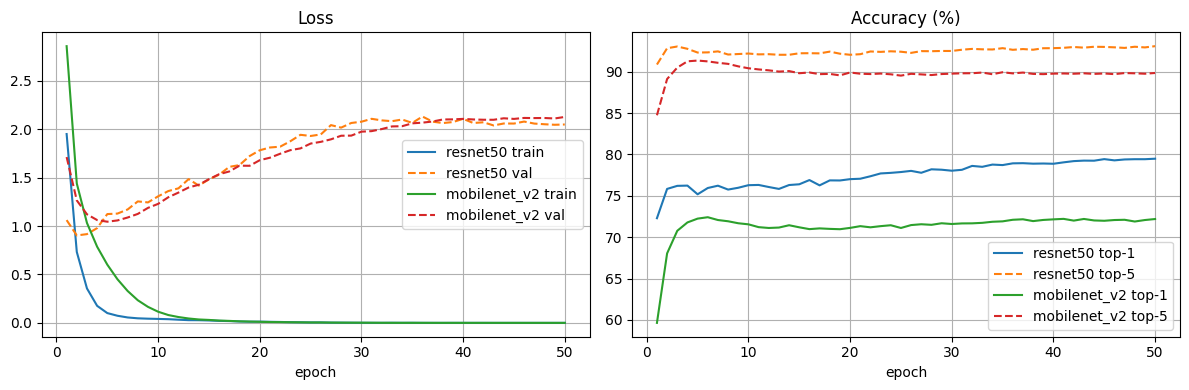

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name in ['resnet50', 'mobilenet_v2']:
    csv_path = f'{OUTPUT_DIR}/{model_name}/training_log.csv'
    if not os.path.exists(csv_path):
        continue
    df = pd.read_csv(csv_path)
    axes[0].plot(df['epoch'], df['train_loss'], label=f'{model_name} train')
    axes[0].plot(df['epoch'], df['val_loss'],   label=f'{model_name} val', linestyle='--')
    axes[1].plot(df['epoch'], df['val_top1'] * 100, label=f'{model_name} top-1')
    axes[1].plot(df['epoch'], df['val_top5'] * 100, label=f'{model_name} top-5', linestyle='--')
    print(f'{model_name}: best val top-1 = {df["val_top1"].max()*100:.2f}%')

axes[0].set_title('Loss');     axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()